<a href="https://colab.research.google.com/github/S8H1L9581/ML-LAB-CH.SC.U4CSE24039/blob/main/9_6_Exercise2_kNN_Euclidean_Distance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 9.6 Exercise 2 — kNN: Calculating Euclidean Distance to Classify a New Entry

**Task:** Calculate the distance between a new entry and other existing values using the **Euclidean distance formula**, and use this to classify the new entry with a kNN classifier.

## Dataset

The dataset is the small table given directly in the exercise:

| Brightness | Saturation | Class |
|-----------|-----------|-------|
| 40 | 20 | Red |
| 50 | 50 | Blue |
| 60 | 90 | Blue |
| 10 | 25 | Red |
| 70 | 70 | Blue |
| 60 | 10 | Red |
| 25 | 80 | Blue |

This is a small, self-contained dataset (no external download needed) used to illustrate exactly how kNN computes distances and votes on a class label.

## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from collections import Counter

%matplotlib inline

## 2. Build the Dataset

In [2]:
data = {
    'Brightness': [40, 50, 60, 10, 70, 60, 25],
    'Saturation': [20, 50, 90, 25, 70, 10, 80],
    'Class':      ['Red', 'Blue', 'Blue', 'Red', 'Blue', 'Red', 'Blue']
}
df = pd.DataFrame(data)
df

,Brightness,Saturation,Class
0,40,20,Red
1,50,50,Blue
2,60,90,Blue
3,10,25,Red
4,70,70,Blue
5,60,10,Red
6,25,80,Blue


## 3. Visualize the Data

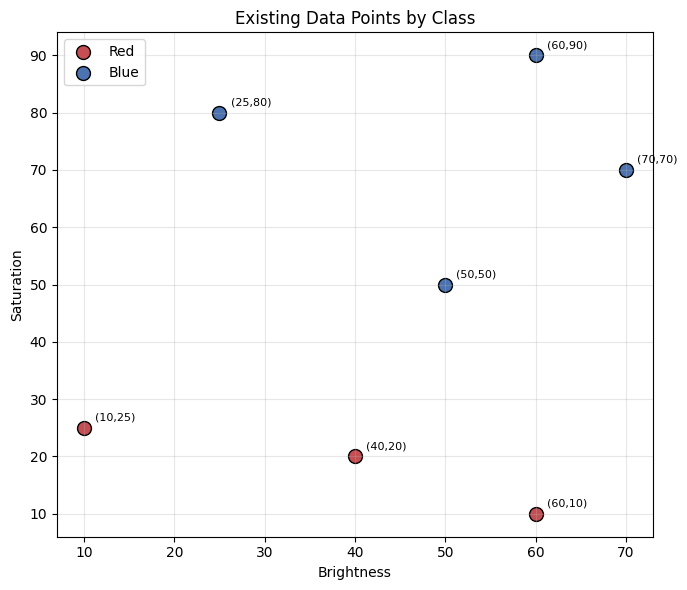

In [3]:
plt.figure(figsize=(7, 6))
for cls, color in [('Red', '#C44E52'), ('Blue', '#4C72B0')]:
    subset = df[df['Class'] == cls]
    plt.scatter(subset['Brightness'], subset['Saturation'], c=color, label=cls, s=100, edgecolor='k')

for _, row in df.iterrows():
    plt.annotate(f"({row['Brightness']},{row['Saturation']})",
                 (row['Brightness'], row['Saturation']),
                 textcoords="offset points", xytext=(8, 5), fontsize=8)

plt.xlabel('Brightness')
plt.ylabel('Saturation')
plt.title('Existing Data Points by Class')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Introduce a New Entry to Classify

Let's classify a **new entry** with `Brightness = 45, Saturation = 40`.

In [4]:
new_entry = {'Brightness': 45, 'Saturation': 40}
print(f"New entry to classify: {new_entry}")

New entry to classify: {'Brightness': 45, 'Saturation': 40}


## 5. Calculate the Euclidean Distance Manually

The Euclidean distance between two points $(x_1, y_1)$ and $(x_2, y_2)$ is:

$$d = \sqrt{(x_2 - x_1)^2 + (y_2 - y_1)^2}$$

We compute this between the new entry and every existing row in the table.

In [5]:
def euclidean_distance(p1, p2):
    return np.sqrt((p1[0] - p2[0]) ** 2 + (p1[1] - p2[1]) ** 2)

new_point = (new_entry['Brightness'], new_entry['Saturation'])

distances = []
for _, row in df.iterrows():
    existing_point = (row['Brightness'], row['Saturation'])
    d = euclidean_distance(new_point, existing_point)
    distances.append(d)

df_result = df.copy()
df_result['Distance to New Entry'] = np.round(distances, 3)
df_result = df_result.sort_values('Distance to New Entry').reset_index(drop=True)
df_result

,Brightness,Saturation,Class,Distance to New Entry
0,50,50,Blue,11.180
1,40,20,Red,20.616
2,60,10,Red,33.541
3,10,25,Red,38.079
4,70,70,Blue,39.051
5,25,80,Blue,44.721
6,60,90,Blue,52.202


### Show the Full Step-by-Step Calculation for Each Row

In [6]:
for _, row in df.iterrows():
    bx, by = row['Brightness'], row['Saturation']
    d = euclidean_distance(new_point, (bx, by))
    print(f"({new_point[0]}, {new_point[1]}) vs ({bx}, {by}) [{row['Class']}]:  "
          f"sqrt(({bx}-{new_point[0]})^2 + ({by}-{new_point[1]})^2) = "
          f"sqrt({(bx-new_point[0])**2} + {(by-new_point[1])**2}) = {d:.3f}")

(45, 40) vs (40, 20) [Red]:  sqrt((40-45)^2 + (20-40)^2) = sqrt(25 + 400) = 20.616
(45, 40) vs (50, 50) [Blue]:  sqrt((50-45)^2 + (50-40)^2) = sqrt(25 + 100) = 11.180
(45, 40) vs (60, 90) [Blue]:  sqrt((60-45)^2 + (90-40)^2) = sqrt(225 + 2500) = 52.202
(45, 40) vs (10, 25) [Red]:  sqrt((10-45)^2 + (25-40)^2) = sqrt(1225 + 225) = 38.079
(45, 40) vs (70, 70) [Blue]:  sqrt((70-45)^2 + (70-40)^2) = sqrt(625 + 900) = 39.051
(45, 40) vs (60, 10) [Red]:  sqrt((60-45)^2 + (10-40)^2) = sqrt(225 + 900) = 33.541
(45, 40) vs (25, 80) [Blue]:  sqrt((25-45)^2 + (80-40)^2) = sqrt(400 + 1600) = 44.721


## 6. Classify Using k-Nearest Neighbors (Majority Vote)

Let's use `k=3`: take the 3 closest points (by Euclidean distance) and let them vote on the class of the new entry.

In [7]:
k = 3
nearest_k = df_result.head(k)
print(f"The {k} nearest neighbors to the new entry are:")
print(nearest_k[['Brightness', 'Saturation', 'Class', 'Distance to New Entry']])

vote_counts = Counter(nearest_k['Class'])
predicted_class = vote_counts.most_common(1)[0][0]

print(f"\nVotes: {dict(vote_counts)}")
print(f"Predicted class for the new entry {new_point}: **{predicted_class}**")

The 3 nearest neighbors to the new entry are:
   Brightness  Saturation Class  Distance to New Entry
0          50          50  Blue                 11.180
1          40          20   Red                 20.616
2          60          10   Red                 33.541

Votes: {'Blue': 1, 'Red': 2}
Predicted class for the new entry (45, 40): **Red**


## 7. Verify with scikit-learn's KNeighborsClassifier

In [8]:
X = df[['Brightness', 'Saturation']].values
y = df['Class'].values

knn = KNeighborsClassifier(n_neighbors=3, metric='euclidean')
knn.fit(X, y)

sklearn_prediction = knn.predict([[new_entry['Brightness'], new_entry['Saturation']]])
print(f"scikit-learn kNN prediction: {sklearn_prediction[0]}")

# Also inspect which neighbors and distances sklearn used, to confirm they match our manual calculation
dist, idx = knn.kneighbors([[new_entry['Brightness'], new_entry['Saturation']]])
print(f"\nDistances from sklearn: {dist[0].round(3)}")
print(f"Neighbor classes from sklearn: {y[idx[0]]}")

scikit-learn kNN prediction: Red

Distances from sklearn: [11.18  20.616 33.541]
Neighbor classes from sklearn: ['Blue' 'Red' 'Red']


Our manual Euclidean-distance calculation matches scikit-learn's built-in kNN implementation exactly, confirming the approach.

## 8. Visualize the New Entry with Its Nearest Neighbors

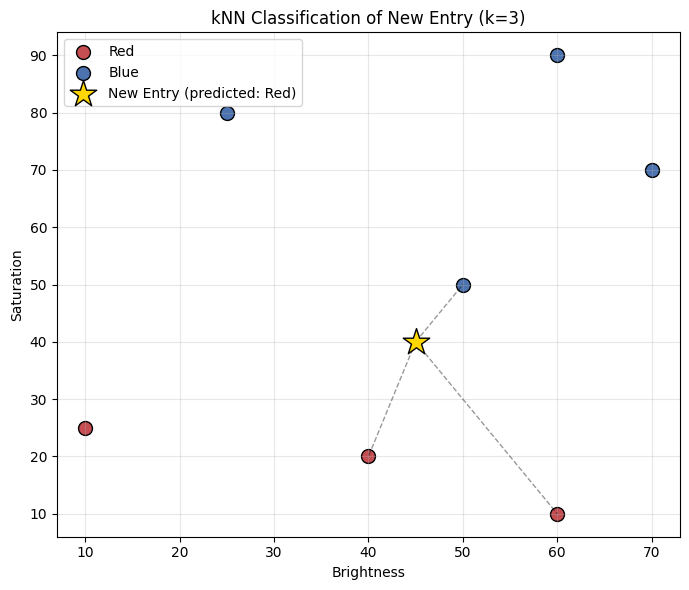

In [9]:
plt.figure(figsize=(7, 6))
for cls, color in [('Red', '#C44E52'), ('Blue', '#4C72B0')]:
    subset = df[df['Class'] == cls]
    plt.scatter(subset['Brightness'], subset['Saturation'], c=color, label=cls, s=100, edgecolor='k')

# Highlight the new entry
plt.scatter(new_point[0], new_point[1], c='gold', marker='*', s=400,
            edgecolor='black', label=f'New Entry (predicted: {predicted_class})', zorder=5)

# Draw lines to the k nearest neighbors
for _, row in nearest_k.iterrows():
    plt.plot([new_point[0], row['Brightness']], [new_point[1], row['Saturation']],
              'k--', alpha=0.4, linewidth=1)

plt.xlabel('Brightness')
plt.ylabel('Saturation')
plt.title(f'kNN Classification of New Entry (k={k})')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 9. Try Different Values of k

Let's see if the predicted class changes depending on how many neighbors we consider.

In [10]:
for k_val in range(1, 8):
    model = KNeighborsClassifier(n_neighbors=k_val, metric='euclidean')
    model.fit(X, y)
    pred = model.predict([[new_entry['Brightness'], new_entry['Saturation']]])[0]
    print(f"k={k_val}: predicted class = {pred}")

k=1: predicted class = Blue
k=2: predicted class = Blue
k=3: predicted class = Red
k=4: predicted class = Red
k=5: predicted class = Red
k=6: predicted class = Blue
k=7: predicted class = Blue


## Conclusion

- We computed the **Euclidean distance** between the new entry `(Brightness=45, Saturation=40)` and every existing data point by hand, using $d = \sqrt{(x_2-x_1)^2 + (y_2-y_1)^2}$.
- Sorting by distance and taking a majority vote among the `k` nearest neighbors gives the kNN prediction — and this matched scikit-learn's built-in `KNeighborsClassifier` exactly.
- This mirrors the core mechanic used in the digit-recognition exercise (9.6.1): kNN always reduces to "measure distance to every known example, then let the closest ones vote," whether the features are two numbers (Brightness/Saturation) or a 1024-length pixel vector.